========== Dataset Summary ==========
Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)
Number of Training Images : 60000
Number of Testing Images  : 10000
Image Size : 28 x 28
Number of Classes : 10


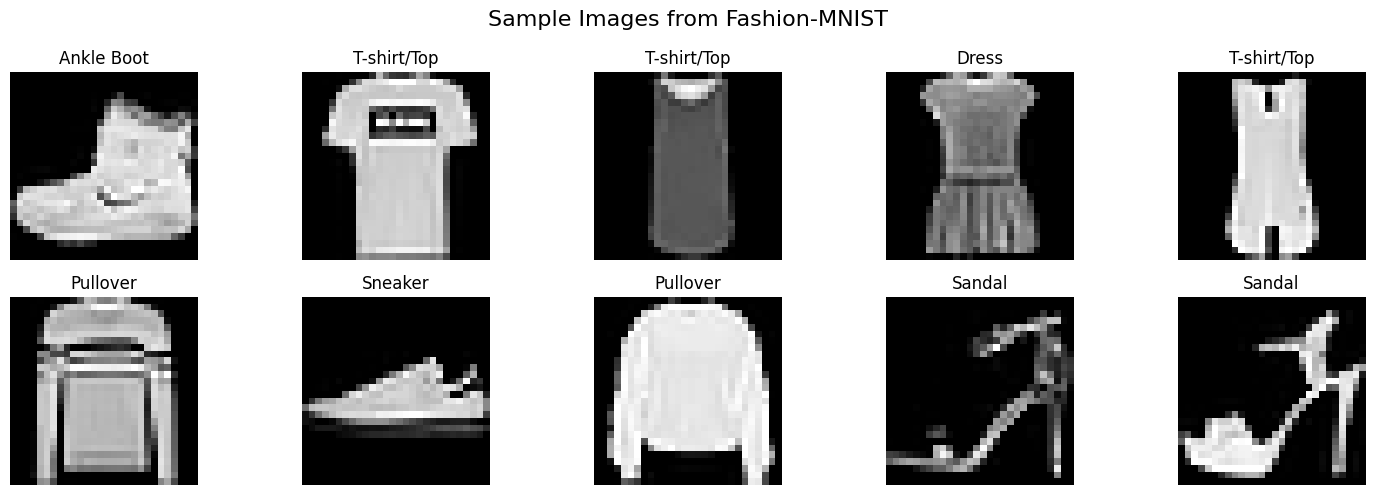

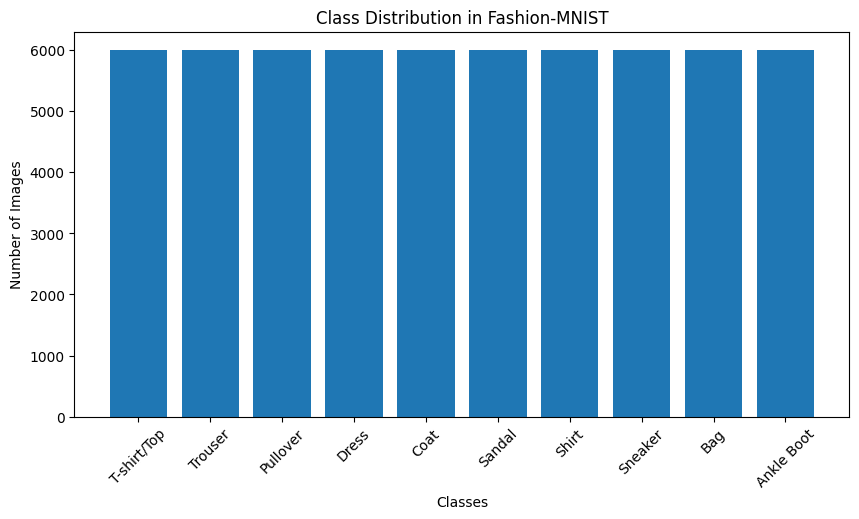

In [1]:
# ============================================
# Task 1: Dataset Exploration
# ============================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class names
class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

# ============================================
# Dataset Summary
# ============================================

print("========== Dataset Summary ==========")
print(f"Training Images Shape : {x_train.shape}")
print(f"Training Labels Shape : {y_train.shape}")
print(f"Testing Images Shape  : {x_test.shape}")
print(f"Testing Labels Shape  : {y_test.shape}")
print(f"Number of Training Images : {len(x_train)}")
print(f"Number of Testing Images  : {len(x_test)}")
print(f"Image Size : {x_train.shape[1]} x {x_train.shape[2]}")
print(f"Number of Classes : {len(class_names)}")

# ============================================
# Display 10 Sample Images
# ============================================

plt.figure(figsize=(15,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.suptitle("Sample Images from Fashion-MNIST", fontsize=16)
plt.tight_layout()
plt.show()

# ============================================
# Plot Class Distribution
# ============================================

class_counts = Counter(y_train)

plt.figure(figsize=(10,5))
plt.bar(class_names, class_counts.values())
plt.title("Class Distribution in Fashion-MNIST")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [2]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ============================================
# Task 2: Data Preprocessing
# ============================================

import tensorflow as tf

# Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# -------------------------------
# Shapes before preprocessing
# -------------------------------
print("Shapes Before Preprocessing")
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

# -------------------------------
# Flatten images (28x28 -> 784)
# -------------------------------
x_train_flat = x_train.reshape(x_train.shape[0], 784)
x_test_flat = x_test.reshape(x_test.shape[0], 784)

# -------------------------------
# Normalize pixel values
# -------------------------------
x_train_flat = x_train_flat.astype("float32") / 255.0
x_test_flat = x_test_flat.astype("float32") / 255.0

# -------------------------------
# One-Hot Encode Labels
# -------------------------------
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=10)

# -------------------------------
# Shapes after preprocessing
# -------------------------------
print("\nShapes After Preprocessing")
print("x_train:", x_train_flat.shape)
print("y_train:", y_train_onehot.shape)
print("x_test :", x_test_flat.shape)
print("y_test :", y_test_onehot.shape)

# -------------------------------
# Verify preprocessing
# -------------------------------
print("\nPixel Value Range:")
print("Minimum:", x_train_flat.min())
print("Maximum:", x_train_flat.max())

print("\nFirst Label (Original):", y_train[0])
print("First Label (One-Hot):", y_train_onehot[0])

Shapes Before Preprocessing
x_train: (60000, 28, 28)
y_train: (60000,)
x_test : (10000, 28, 28)
y_test : (10000,)

Shapes After Preprocessing
x_train: (60000, 784)
y_train: (60000, 10)
x_test : (10000, 784)
y_test : (10000, 10)

Pixel Value Range:
Minimum: 0.0
Maximum: 1.0

First Label (Original): 9
First Label (One-Hot): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [4]:
# ============================================
# Task 3: Model Construction
# ============================================

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense

# Build the MLP model
model = Sequential([
    Input(shape=(784,)),              # Input Layer
    Dense(128, activation='relu'),    # Hidden Layer 1
    Dense(64, activation='relu'),     # Hidden Layer 2
    Dense(10, activation='softmax')   # Output Layer
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ============================================
# Task 4: Model Training
# ============================================

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train_flat,
    y_train_onehot,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8209 - loss: 0.5031 - val_accuracy: 0.8491 - val_loss: 0.4144
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8616 - loss: 0.3787 - val_accuracy: 0.8691 - val_loss: 0.3582
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8743 - loss: 0.3422 - val_accuracy: 0.8614 - val_loss: 0.3662
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8818 - loss: 0.3165 - val_accuracy: 0.8739 - val_loss: 0.3416
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8880 - loss: 0.2981 - val_accuracy: 0.8792 - val_loss: 0.3259
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8953 - loss: 0.2827 - val_accuracy: 0.8739 - val_loss: 0.3509
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9001 - loss: 0.2685 - val_accuracy: 0.8848 - val_loss: 0.3216
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9028 - loss: 0.2585 -

In [6]:
# ============================================
# Task 5: Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import numpy as np

# Predict probabilities on test data
y_pred_prob = model.predict(x_test_flat)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded test labels to class labels
y_true = np.argmax(y_test_onehot, axis=1)

# --------------------------------------------
# Evaluation Metrics
# --------------------------------------------

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("========== Model Evaluation ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# --------------------------------------------
# Confusion Matrix
# --------------------------------------------

cm = confusion_matrix(y_true, y_pred)

print("\nConfusion Matrix:")
print(cm)

# --------------------------------------------
# Classification Report
# --------------------------------------------

print("\nClassification Report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "T-shirt/Top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle Boot"
    ]
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
========== Model Evaluation ==========
Accuracy : 0.8843
Precision: 0.8853
Recall   : 0.8843
F1-score : 0.8843

Confusion Matrix:
[[804   0   7  54   3   2 125   0   5   0]
 [  4 964   2  24   3   0   2   0   1   0]
 [ 18   0 807  18  70   1  81   0   5   0]
 [  9   3  10 917  30   0  26   0   5   0]
 [  1   0 128  32 769   0  67   0   3   0]
 [  1   0   0   1   0 970   0  21   1   6]
 [104   1  67  46  47   0 723   0  12   0]
 [  0   0   0   0   0  15   0 965   1  19]
 [  5   0   3   6   3   3   3   3 973   1]
 [  0   0   0   0   0  13   1  35   0 951]]

Classification Report:
              precision    recall  f1-score   support

 T-shirt/Top       0.85      0.80      0.83      1000
     Trouser       1.00      0.96      0.98      1000
    Pullover       0.79      0.81      0.80      1000
       Dress       0.84      0.92      0.87      1000
        Coat       0.83      0.77      0.80      1000
      Sandal       0.97      0.97      0.97      

In [7]:
!pip install scikeras

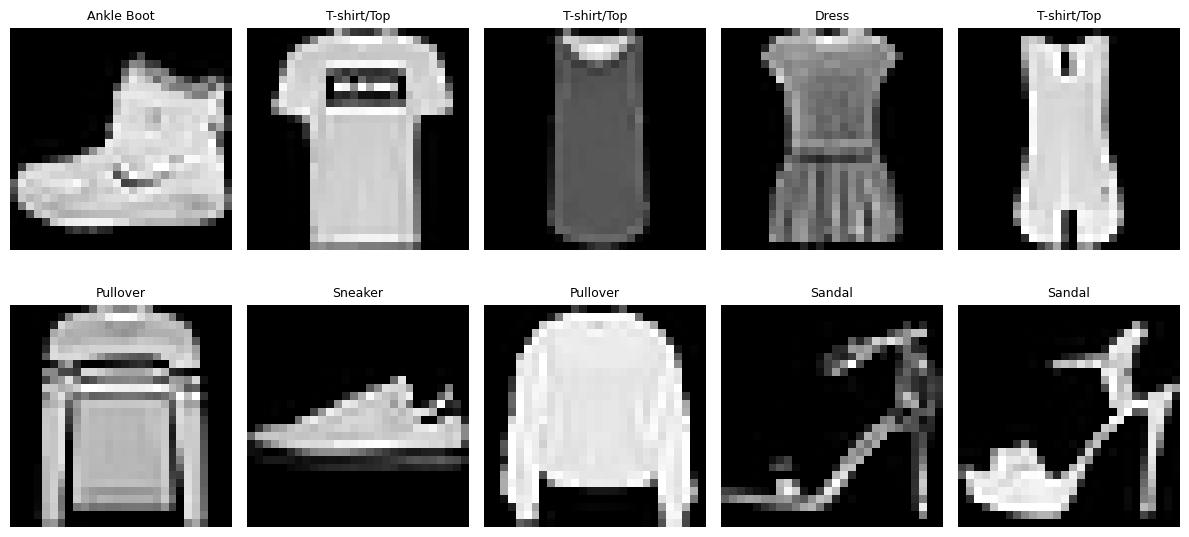

In [8]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()

plt.savefig("sample_images.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

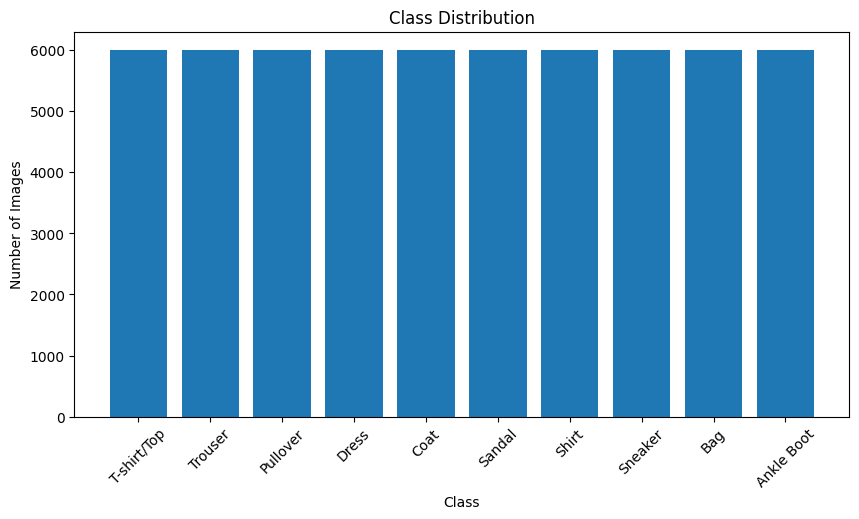

In [9]:
from collections import Counter

counts = Counter(y_train)

plt.figure(figsize=(10,5))

plt.bar(class_names, counts.values())

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution")

plt.xticks(rotation=45)

plt.savefig("class_distribution.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

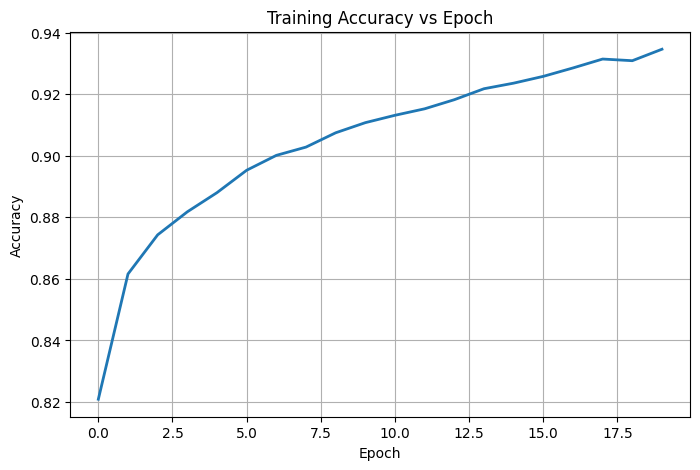

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"],
         linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy vs Epoch")

plt.grid(True)

plt.savefig("training_accuracy.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

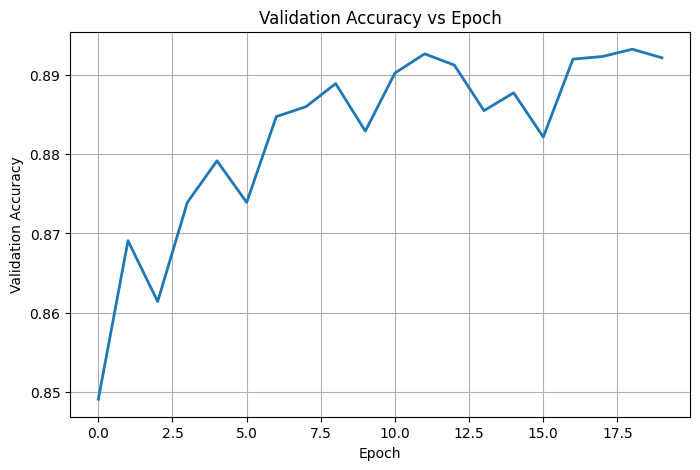

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_accuracy"],
         linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy vs Epoch")

plt.grid(True)

plt.savefig("validation_accuracy.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

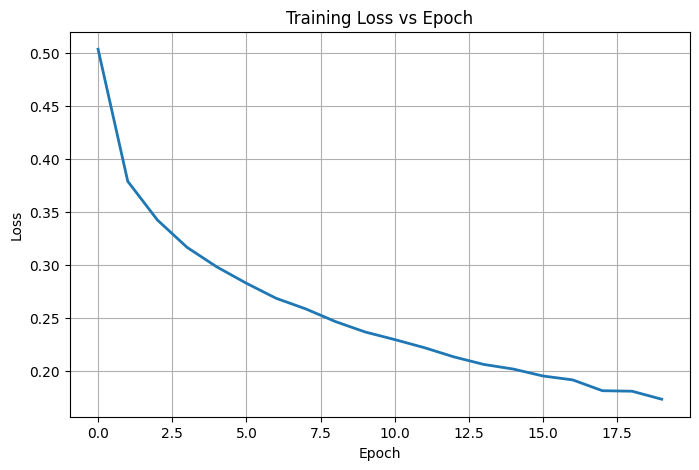

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"],
         linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss vs Epoch")

plt.grid(True)

plt.savefig("training_loss.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

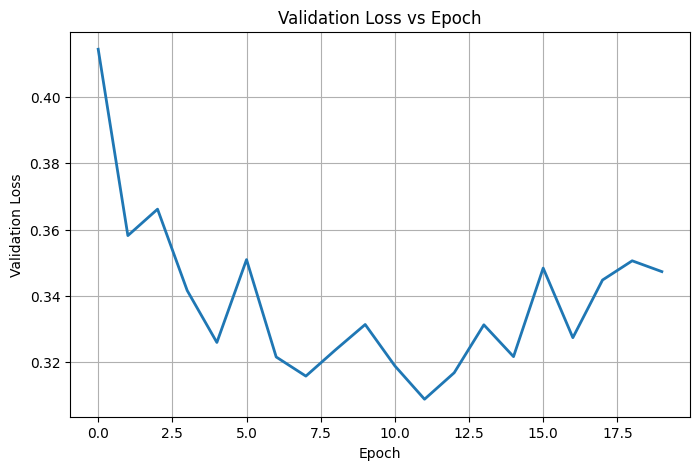

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["val_loss"],
         linewidth=2)

plt.xlabel("Epoch")

plt.ylabel("Validation Loss")

plt.title("Validation Loss vs Epoch")

plt.grid(True)

plt.savefig("validation_loss.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

<Figure size 800x800 with 0 Axes>

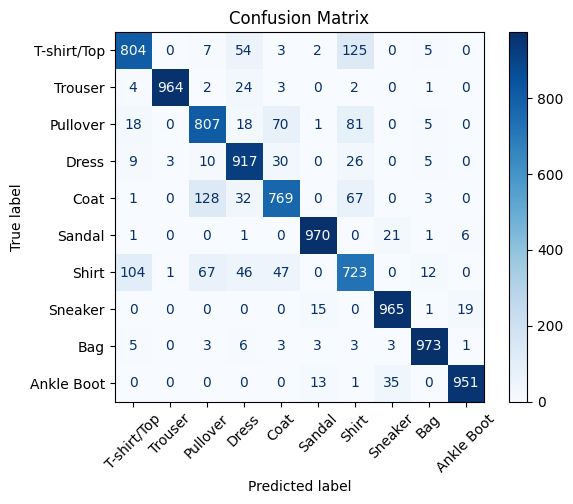

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues",
          xticks_rotation=45)

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from scikeras.wrappers import KerasClassifier

from sklearn.model_selection import RandomizedSearchCV, train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import numpy as np

In [16]:
def create_model(hidden_layers=2,
                 hidden_neurons=128,
                 learning_rate=0.001,
                 optimizer="adam",
                 activation="relu",
                 dropout_rate=0.0):

    model = Sequential()
    model.add(Input(shape=(784,)))

    for i in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))

        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(10, activation="softmax"))

    if optimizer == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [17]:
mlp = KerasClassifier(
    model=create_model,
    verbose=0
)

In [18]:
param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30],
    "model__optimizer": ["adam", "sgd", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5]
}

In [19]:
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring="accuracy",
    random_state=42,
    n_jobs=1
)

In [20]:
import sklearn
import scikeras
import tensorflow as tf

print("scikit-learn:", sklearn.__version__)
print("SciKeras:", scikeras.__version__)
print("TensorFlow:", tf.__version__)

scikit-learn: 1.5.2
SciKeras: 0.13.0
TensorFlow: 2.20.0


In [21]:
import keras
print("Keras:", keras.__version__)

Keras: 3.13.2


In [22]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.5.2

Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [23]:
random_search.fit(x_train_flat, y_train_onehot)


RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7a995d7c9760>, verbose=0),
                   n_iter=5, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout_rate': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__hidden_neurons': [32, 64, 128,
                                                                  256],
                                        'model__learning_rate': [0.1, 0.01,
                                                                 0.001],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   random_state=42, scoring='accuracy')

In [24]:
# ============================================
# Task 4: Best Hyperparameters
# ============================================

print("========== Best Hyperparameters ==========\n")

print(random_search.best_params_)

print("\nBest Cross Validation Accuracy:")

print(random_search.best_score_)

========== Best Hyperparameters ==========

{'model__optimizer': 'rmsprop', 'model__learning_rate': 0.001, 'model__hidden_neurons': 128, 'model__hidden_layers': 3, 'model__dropout_rate': 0.2, 'model__activation': 'tanh', 'epochs': 30, 'batch_size': 32}

Best Cross Validation Accuracy:
0.8888999999999999


In [25]:
# ============================================
# Task 5: Retrain Optimized Model
# ============================================

best_model = random_search.best_estimator_

In [26]:
best_model.fit(
    x_train_flat,
    y_train_onehot
)

KerasClassifier(
	model=<function create_model at 0x7a995d7c9760>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=32
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=30
	class_weight=None
	model__optimizer=rmsprop
	model__learning_rate=0.001
	model__hidden_neurons=128
	model__hidden_layers=3
	model__dropout_rate=0.2
	model__activation=tanh
)

In [27]:
print(y_pred.shape)
print(y_true.shape)

(10000,)
(10000,)


In [28]:
print(y_pred[:5])

[9 2 1 1 6]


In [29]:
# ============================================
# Task 6: Evaluate Optimized Model
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import numpy as np

# --------------------------------------------
# Predictions
# --------------------------------------------

y_pred = best_model.predict(x_test_flat)

# Convert one-hot predictions to class labels
if len(y_pred.shape) > 1:
    y_pred = np.argmax(y_pred, axis=1)

# Convert one-hot true labels to class labels
y_true = np.argmax(y_test_onehot, axis=1)

# --------------------------------------------
# Evaluation Metrics
# --------------------------------------------

optimized_accuracy = accuracy_score(y_true, y_pred)

optimized_precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

optimized_cm = confusion_matrix(y_true, y_pred)

# --------------------------------------------
# Display Results
# --------------------------------------------

print("========== Optimized Model ==========\n")

print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1-score : {optimized_f1:.4f}")

print("\nConfusion Matrix:\n")
print(optimized_cm)

print("\nClassification Report:\n")

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

========== Optimized Model ==========

Accuracy : 0.8840
Precision: 0.8842
Recall   : 0.8840
F1-score : 0.8838

Confusion Matrix:

[[848   1   5  24   1   1 110   0  10   0]
 [  1 972   1  18   4   0   3   0   1   0]
 [ 19   0 756  17 113   1  91   0   3   0]
 [ 19   9   4 904  30   0  29   0   5   0]
 [  1   1  72  35 816   0  70   0   5   0]
 [  0   0   0   0   0 952   0  26   2  20]
 [131   0  64  30  68   0 694   0  13   0]
 [  0   0   0   0   0  17   0 964   0  19]
 [  4   0   2   6   2   2   3   4 977   0]
 [  0   0   0   0   0   4   0  38   1 957]]

Classification Report:

              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.85      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.84      0.76      0.79      1000
       Dress       0.87      0.90      0.89      1000
        Coat       0.79      0.82      0.80      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.69      0.69 

In [30]:
y_pred_baseline = model.predict(x_test_flat)
y_pred_baseline = np.argmax(y_pred_baseline, axis=1)

y_true = np.argmax(y_test_onehot, axis=1)

baseline_accuracy = accuracy_score(y_true, y_pred_baseline)
baseline_precision = precision_score(y_true, y_pred_baseline, average="weighted")
baseline_recall = recall_score(y_true, y_pred_baseline, average="weighted")
baseline_f1 = f1_score(y_true, y_pred_baseline, average="weighted")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Optimized": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]
})

# Round values to 4 decimal places
comparison.iloc[:, 1:] = comparison.iloc[:, 1:].round(4)

print(comparison)

      Metric  Baseline  Optimized
0   Accuracy    0.8843     0.8840
1  Precision    0.8853     0.8842
2     Recall    0.8843     0.8840
3   F1-score    0.8843     0.8838


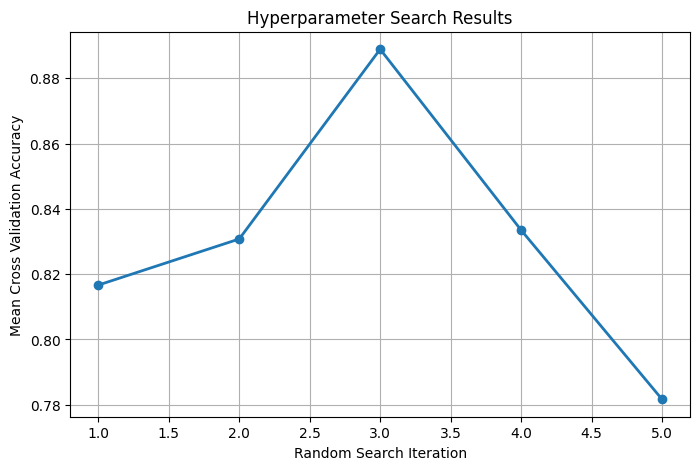

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert CV results to DataFrame
results = pd.DataFrame(random_search.cv_results_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(results["mean_test_score"]) + 1),
    results["mean_test_score"],
    marker='o',
    linewidth=2
)

plt.xlabel("Random Search Iteration")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("Hyperparameter Search Results")

plt.grid(True)

plt.savefig(
    "hyperparameter_search_results.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

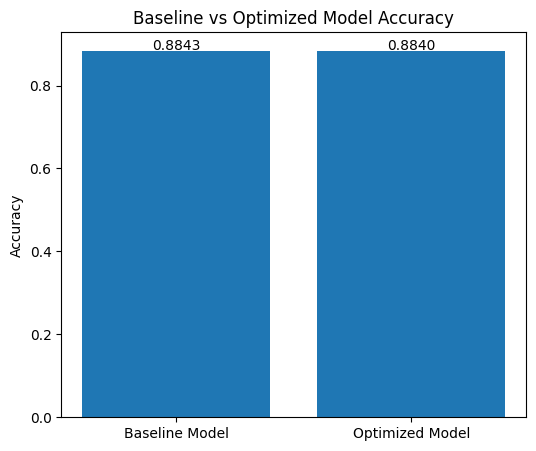

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.bar(
    ["Baseline Model", "Optimized Model"],
    [baseline_accuracy, optimized_accuracy]
)

plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Model Accuracy")

# Display values on bars
for i, value in enumerate([baseline_accuracy, optimized_accuracy]):
    plt.text(i, value + 0.002, f"{value:.4f}", ha='center')

plt.savefig(
    "best_model_accuracy_comparison.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [34]:
import os

for file in os.listdir():
    if file.endswith(".eps"):
        print(file)

hyperparameter_search_results.eps
sample_images.eps
training_accuracy.eps
class_distribution.eps
validation_loss.eps
confusion_matrix.eps
best_model_accuracy_comparison.eps
validation_accuracy.eps
training_loss.eps
